## 1. Định nghĩa vấn đề

Tệp diabetes_prediction_dataset.csv chứa dữ liệu y tế và nhân khẩu học của các bệnh nhân cùng với tình trạng bệnh tiểu đường của họ (dương tính hoặc âm tính). Tệp này bao gồm nhiều đặc trưng khác nhau như tuổi, giới tính, chỉ số khối cơ thể (BMI), tình trạng tăng huyết áp, bệnh tim, lịch sử hút thuốc, chỉ số HbA1c và mức đường huyết. Bộ dữ liệu này có thể được sử dụng để xây dựng các mô hình học máy giúp dự đoán khả năng mắc bệnh tiểu đường ở bệnh nhân dựa trên lịch sử y tế và các thông tin nhân khẩu học của họ.

Giải thích thuật ngữ: 
+ Demographic data: Dữ liệu nhân khẩu học (tuổi, giới, nơi ở...).

+ Features: Đặc trưng (các biến đầu vào cho mô hình).

+ Hypertension: Tăng huyết áp.

+ HbA1c level: Chỉ số HbA1c (chỉ số đường huyết trung bình trong 3 tháng).

+ Blood glucose level: Mức đường huyết.

## 2. Chuẩn bị vấn đề

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

## 3. Thống kê mô tả


## 3.1 Hiển thị một số thông tin về dữ liệu

+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [8]:
# shape
print(f'+ Shape: {df.shape}')
# types
print(f'+ Data Types: \n{df.dtypes}')

+ Shape: (100000, 9)
+ Data Types: 
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


**Nhận xét:** Bộ dữ liệu gồm 100000 mẫu, 8 đặc trưng và 1 đặc trung là kết quả tình trạng có tiểu đường hay không.

In [15]:
print("Dữ liệu đầu vào:")
df.head()

Dữ liệu đầu vào:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## 3.2 Kiểm tra tính toàn vẹn của dữ liệu

In [12]:
print("\n Dữ kiệu bị null:")
df.isnull().sum()


 Dữ kiệu bị null:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## 3.3 Các tính chất thống kê trên dữ liệu số

In [17]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## 4. Chuẩn bị dữ liệu

## 4.1 Kiểm tra các cột chứa chữ (object) và chuyển đổi sang số

In [16]:
# Ví dụ: Cột 'Gender' có 'Male'/'Female' sẽ thành 1/0
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # Lưu lại để tra cứu nếu cần
    print(f"Đã chuyển đổi cột '{column}': {le.classes_} -> {list(range(len(le.classes_)))}")

Đã chuyển đổi cột 'gender': ['Female' 'Male' 'Other'] -> [0, 1, 2]
Đã chuyển đổi cột 'smoking_history': ['No Info' 'current' 'ever' 'former' 'never' 'not current'] -> [0, 1, 2, 3, 4, 5]


In [17]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


## 4.2 Tách đặc trưng (X) và nhãn (y)

In [20]:
# diabetes là cột nhãn (1: Tiểu đường, 0: Không)
X = df.drop('diabetes', axis=1).values
y = df['diabetes'].values

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## 4.3 Chuẩn hóa dữ liệu (Scaling) 

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [23]:
X_test_scaled = scaler.transform(X_test)

# 5. Huấn luyện SVM 

## 5.1 Huấn luyện dữ liệu bằng SVM với kernel linear

In [24]:

clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
# Đánh giá
print("\nĐộ chính xác:", clf.score(X_test, y_test))


Độ chính xác: 0.95855


## 5.2 Tìm mô hình tốt nhất

In [26]:
# Danh sách các kernel cần thử nghiệm
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

best_svm = None
best_val_acc = -1
best_kernel = None

print("\n--- Tìm kiếm Kernel tối ưu ---")
for kernel in kernels:
    # Huấn luyện mô hình
    # probability=True để hỗ trợ tính xác suất nếu cần sau này
    clf = svm.SVC(kernel=kernel, probability=True, random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Đánh giá trên tập Test
    acc = clf.score(X_test_scaled, y_test)
    print(f"Kernel: {kernel:10s} -> Accuracy: {acc:.4f}")
    
    # Lưu lại kết quả tốt nhất
    if acc > best_val_acc:
        best_val_acc = acc
        best_svm = clf
        best_kernel = kernel

print(f"\n=> Kết quả: Kernel tốt nhất là '{best_kernel}' với độ chính xác {best_val_acc:.4f}")


--- Tìm kiếm Kernel tối ưu ---
Kernel: linear     -> Accuracy: 0.9595
Kernel: poly       -> Accuracy: 0.9632
Kernel: rbf        -> Accuracy: 0.9624
Kernel: sigmoid    -> Accuracy: 0.9190

=> Kết quả: Kernel tốt nhất là 'poly' với độ chính xác 0.9632


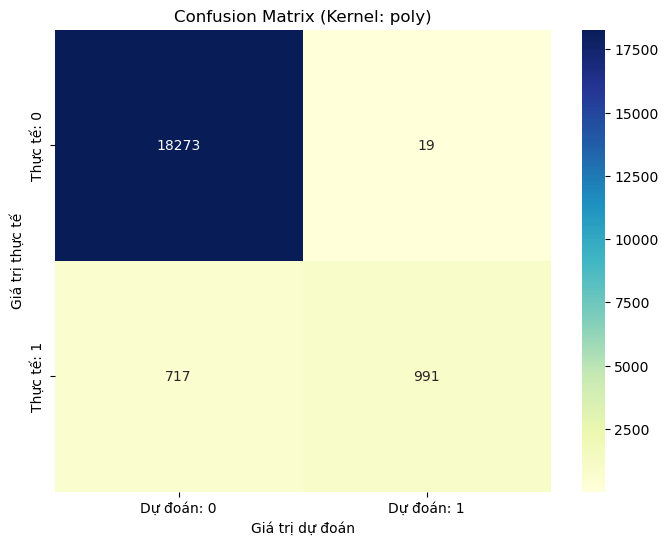


--- Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.98      0.58      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.97      0.79      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [27]:
# Dự đoán lại bằng mô hình tốt nhất đã lưu
y_pred = best_svm.predict(X_test_scaled)

# 1. Vẽ Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Thực tế: 0', 'Thực tế: 1'], columns=['Dự đoán: 0', 'Dự đoán: 1'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix (Kernel: {best_kernel})')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()

# 2. Báo cáo phân loại chi tiết
print("\n--- Báo cáo phân loại (Classification Report) ---")
print(classification_report(y_test, y_pred))